In [2]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from scipy.stats import boxcox

# Decomposition

Decomposition into 3 components of seasonal, trend, and residual.

Multiplicative and Additive Models are different ways of decomposing the time series. 

Can use a log transform to turn multiplicative into an additive model

### Classical Decomposition Approach

1. Use MA/Rolling Average to compute Trend
2. Detrend the Series 
    - for additive this is Y minus Trend
    - for multiplicative this is Y / Trend
3. Compute Seasonal by taking average of de-trended series
4. Analysis Residuals
    - Additive Residuals are R = Y minus Trend minus Residual
    - Multiplicative Residuals are R = Y / (Trend * Residual)

In [3]:
df = pd.read_csv(f'Youtube\Egor Books\Youtube-main\Youtube-main\Time-Series-Crash-Course\AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'], format = '%Y-%m')
df.set_index('Month', inplace=True)

<Axes: title={'center': 'Raw Data'}, xlabel='Month'>

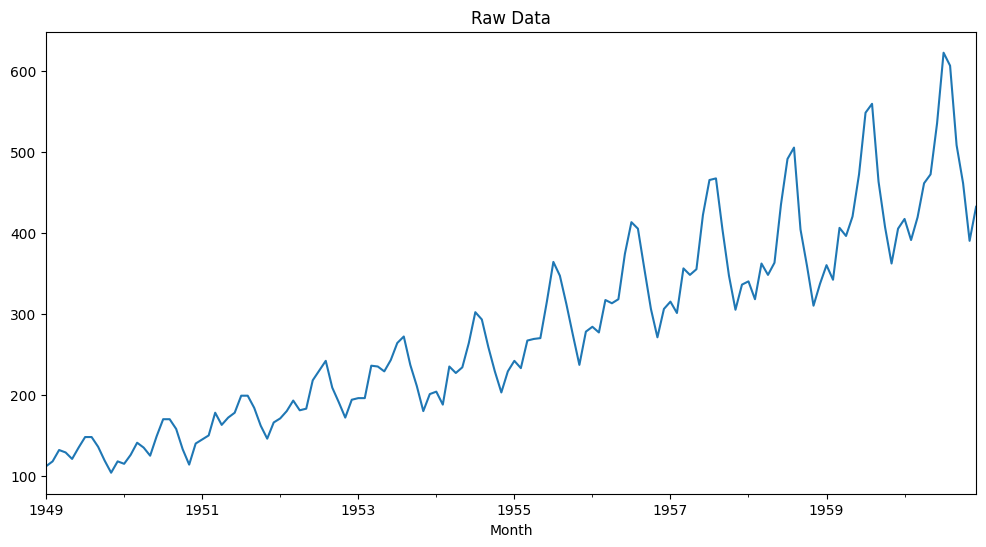

In [4]:
#Seasonality, Trend observed. Fluctuations are not constant => Multiplicative model
df['#Passengers'].plot(title='Raw Data', figsize=(12,6))

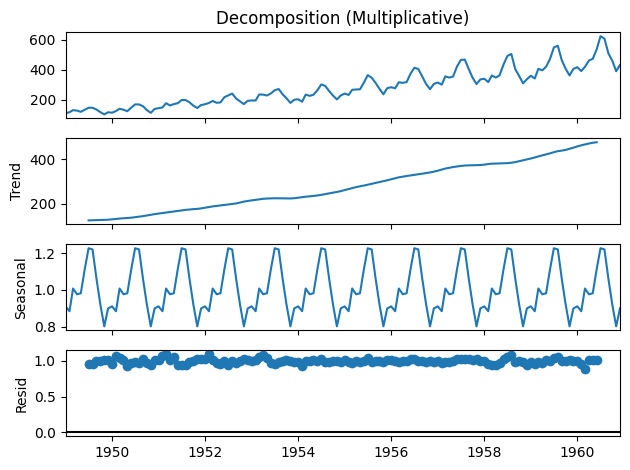

In [5]:
#Decomposition (rename because plotting directly via SM uses the same name)
df.rename(columns={'#Passengers':'Decomposition (Multiplicative)'}, inplace=True)
decomposition_multiplicative = sm.tsa.seasonal_decompose(df['Decomposition (Multiplicative)'], model='multiplicative')
decomposition_multiplicative.plot()
plt.show()

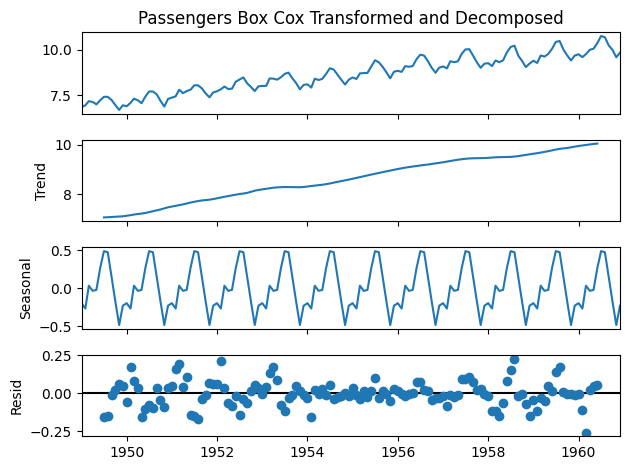

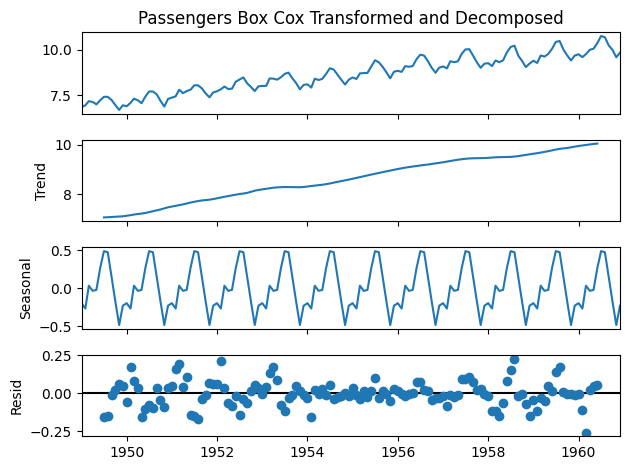

In [13]:
#Additive model by taking Log Transformed
df['Passengers Box Cox Transformed and Decomposed'] , lam = boxcox(df['Decomposition (Multiplicative)'])
#Decompose
additive_decomposition = sm.tsa.seasonal_decompose(df['Passengers Box Cox Transformed and Decomposed'],
                                                   model='additive')
additive_decomposition.plot()

## Auto and Partial Autocorrelation

Autocorrelation can reveal information about
1. Seasonality (e.g., multiples of 12 peaks)
2. Trend (e.g., high corr for recent lags indicate need for differencing)

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib import dates as mdate

Text(0, 0.5, 'Correlation')

<Figure size 1200x600 with 0 Axes>

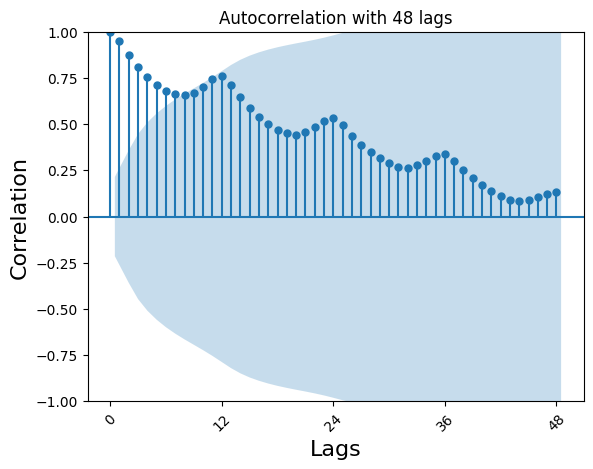

In [46]:
#Use plot_acf figure, specify lags, confidence interval
fig = plt.figure(figsize=(12,6))
plot_acf(df['Decomposition (Multiplicative)'], lags=48, alpha = 0.01, title='Autocorrelation with 48 lags')
plt.xlabel('Lags', fontsize=16)
plt.xticks(np.arange(0,49,12), rotation=45)
plt.ylabel('Correlation', fontsize=16)

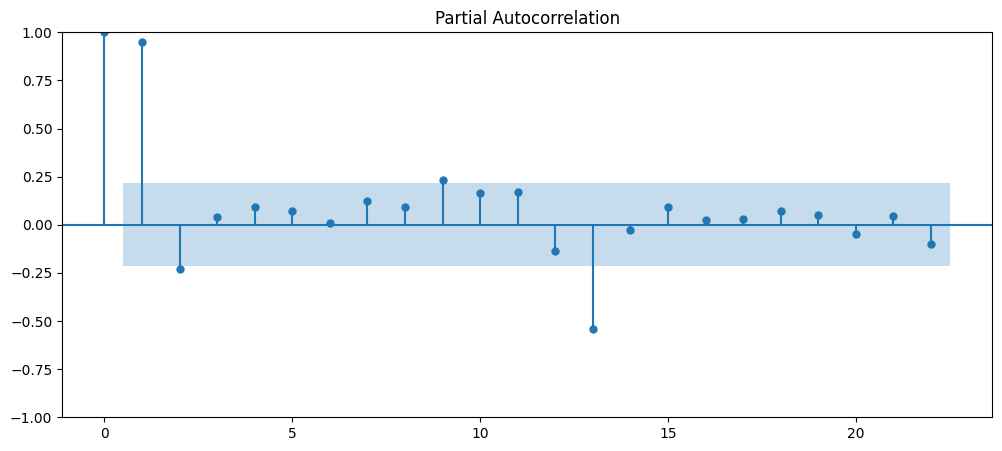

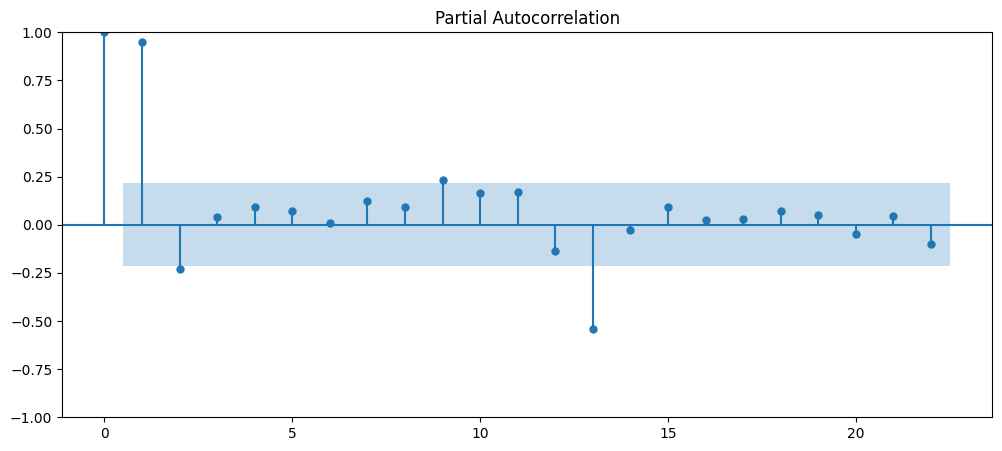

In [52]:
#Partial Autocorrelation - particularly useful for AR components 
plt.rc('figure', figsize=(12,5))
#Partial Plotting Parameters : method = Yule Walker Equation without adjustment ('ywm'). 
#Other methods is ols, ols-adjusted, levinson-durbin, etc...
plot_pacf(df['Decomposition (Multiplicative)'] , method='ywm', alpha = 0.01)

## Basic Forecasting Techniques

1. Average Forecast (future values are equally weighted average observations)
2. Naive forecasting (future value is the prior value e.g., martingale)
3. Seasonal naive forecasting (future value is most recent observation of the same season)
4. Drift model (previous value + a linear change)

In [67]:
df = pd.read_csv(f'Youtube/Egor Books/Youtube-main/Youtube-main/Time-Series-Crash-Course/AirPassengers.csv', index_col = [0], parse_dates =True)
df.index = pd.to_datetime(df.index, format='%Y-%m-%d')

In [68]:
#Set up training and test split : first define training size
training_size = int(len(df) * 0.2)
#Select up training data up to the specified size
training_data = df.iloc[:-training_size]
#Testing data is the remainder
testing_data = df.iloc[-training_size:]

C:\Users\Phillip\AppData\Local\Temp\ipykernel_12168\3673343215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing_data['mean_forecast'] = training_data['#Passengers'].mean()
C:\Users\Phillip\AppData\Local\Temp\ipykernel_12168\3673343215.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing_data['naive_forecast'] = training_data['#Passengers'].iloc[-1]


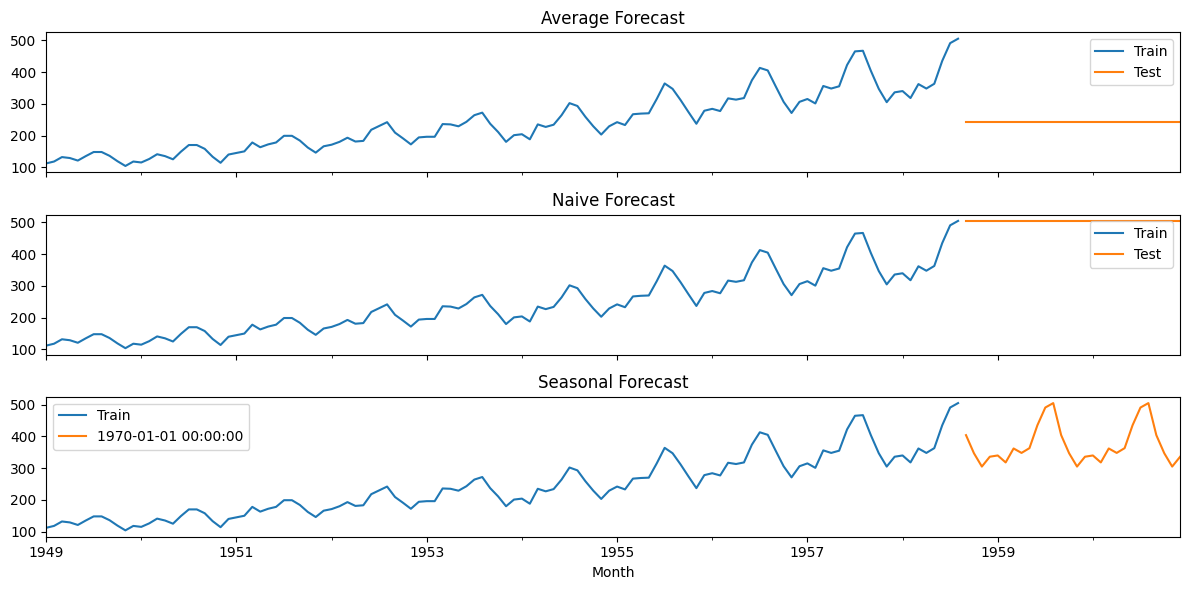

In [118]:
#Average Forecasting (Method 1)
testing_data['mean_forecast'] = training_data['#Passengers'].mean()
#Naive Forecasting (Method 2) or Random Walk without Drift
testing_data['naive_forecast'] = training_data['#Passengers'].iloc[-1]



#Plot shows just the straight line of the testing data
fig, axs = plt.subplots(3,1, figsize=(12,6))
training_data['#Passengers'].plot(label='Train', ax = axs[0])
testing_data['mean_forecast'].plot(label='Test', ax = axs[0])
axs[0].legend()
axs[0].set_title('Average Forecast')

training_data['#Passengers'].plot(label='Train', ax = axs[1])
testing_data['naive_forecast'].plot(label='Test', ax = axs[1])
axs[1].legend()
axs[1].set_title('Naive Forecast')

training_data['#Passengers'].plot(label='Train', ax = axs[2], sharex=True)
Seasonal_Naive_Forecast.T.plot(label='Test', ax=axs[2])
axs[2].legend()
axs[2].set_title('Seasonal Forecast')

plt.tight_layout()

In [116]:
#Seasonal Data (Method 3)
    #Create a column that shows the month counter (m = 12)
    #Monthly data with yearly seasonality is m = 12, weekly is m = 52
training_data['month_number'] = pd.DatetimeIndex(training_data.index).month
testing_data['month_number'] = pd.DatetimeIndex(testing_data.index).month

Date = []
Seasonal_Naive_Forecast = {}

for row_id, row in testing_data.iterrows():
    month = row['month_number']
    #Forecast is the last value that shares the same month number
    forecast = training_data['#Passengers'].loc[training_data['month_number']==month].iloc[-1]
    #Append the forecast into the array
    Seasonal_Naive_Forecast[row_id] = forecast

Seasonal_Naive_Forecast = pd.DataFrame(Seasonal_Naive_Forecast, index = [0])
Seasonal_Naive_Forecast.index = pd.to_datetime(Seasonal_Naive_Forecast.index)

C:\Users\Phillip\AppData\Local\Temp\ipykernel_12168\390804172.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_data['month_number'] = pd.DatetimeIndex(training_data.index).month
C:\Users\Phillip\AppData\Local\Temp\ipykernel_12168\390804172.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing_data['month_number'] = pd.DatetimeIndex(testing_data.index).month
